## Install Dependencies


In [25]:
# Install required libraries (run once)
!pip install tensorflow streamlit numpy matplotlib --quiet
# Install once (run in notebook)
!pip install wordfreq

## Import Libraries

In [26]:
import os
import random
import string
import pickle
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, TimeDistributed

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


## Common English Word List
Base vocabulary of ~10000 words used to generate training data.

In [27]:
from wordfreq import top_n_list

# Get top 6000 English words
BASE_WORDS = top_n_list("en", 10000)

# Clean words
BASE_WORDS = list({
    w.lower() for w in BASE_WORDS
    if len(w) >= 3 and w.isalpha()
})

print(f"Total unique base words: {len(BASE_WORDS)}")
print("Sample words:", BASE_WORDS[:10])

Total unique base words: 9602
Sample words: ['traded', 'doctor', 'snow', 'shifting', 'todd', 'donald', 'squad', 'marked', 'compliment', 'reader']


## Spelling Mistake Generator Functions
Five realistic error types are simulated.

In [28]:
def swap_adjacent(word):
    """Swap two adjacent characters  e.g.  the -> teh"""
    if len(word) < 2: return word
    i = random.randint(0, len(word) - 2)
    lst = list(word)
    lst[i], lst[i+1] = lst[i+1], lst[i]
    return "".join(lst)

def delete_char(word):
    """Remove a random character  e.g.  environment -> enviroment"""
    if len(word) < 2: return word
    i = random.randint(0, len(word) - 1)
    return word[:i] + word[i+1:]

def insert_char(word):
    """Insert a random extra character  e.g.  copy -> coppy"""
    i = random.randint(0, len(word))
    ch = random.choice(string.ascii_lowercase)
    return word[:i] + ch + word[i:]

def replace_char(word):
    """Replace with a keyboard-neighbour key  e.g.  receive -> recieve"""
    keyboard_neighbors = {
        "a":"sqwz","b":"vghn","c":"xdfv","d":"srfce","e":"wrsdf",
        "f":"drtgv","g":"ftyhb","h":"gyujn","i":"ujko","j":"huikm",
        "k":"jiol","l":"kop","m":"njk","n":"bhjm","o":"iklp",
        "p":"ol","q":"wa","r":"edft","s":"awedxz","t":"rfgy",
        "u":"yhji","v":"cfgb","w":"qase","x":"zsdc","y":"tghu","z":"asx"
    }
    if len(word) < 1: return word
    i = random.randint(0, len(word) - 1)
    ch = word[i].lower()
    neighbors = keyboard_neighbors.get(ch, string.ascii_lowercase)
    return word[:i] + random.choice(neighbors) + word[i+1:]

def double_char(word):
    """Double a random character  e.g.  running -> runnning"""
    if len(word) < 1: return word
    i = random.randint(0, len(word) - 1)
    return word[:i] + word[i] + word[i:]

MUTATIONS = [swap_adjacent, delete_char, insert_char, replace_char, double_char]

def introduce_mistake(word):
    if len(word) < 3:
        return word

    ops = ['swap', 'delete', 'insert', 'replace']
    op = random.choice(ops)

    i = random.randint(0, len(word)-1)

    if op == 'swap' and i < len(word)-1:
        return word[:i] + word[i+1] + word[i] + word[i+2:]

    elif op == 'delete':
        return word[:i] + word[i+1:]

    elif op == 'insert':
        ch = random.choice(string.ascii_lowercase)
        return word[:i] + ch + word[i:]

    elif op == 'replace':
        ch = random.choice(string.ascii_lowercase)
        return word[:i] + ch + word[i+1:]

    return word

# Demo
print("Mutation examples:")
for w in ["the", "environment", "computer", "language", "algorithm"]:
    print(f"  {w:15s}  ->  {introduce_mistake(w)}")

Mutation examples:
  the              ->  tshe
  environment      ->  eynvironment
  computer         ->  compxuter
  language         ->  laguage
  algorithm        ->  lagorithm


## Generate Dataset (100,000 pairs)

In [29]:
def generate_dataset(n):
    pairs = []

    while len(pairs) < n:
        word = random.choice(BASE_WORDS)

        if random.random() < 0.7:
            noisy = introduce_mistake(word)

            # add second mistake sometimes
            if random.random() < 0.3:
                noisy = introduce_mistake(noisy)

            pairs.append((noisy, word))
        else:
            pairs.append((word, word))

    return pairs

## Preprocessing (Tokenization & Encoding)

In [30]:
# Special tokens
PAD_CHAR   = "<PAD>"   # index 0
START_CHAR = "<SOS>"   # index 1
END_CHAR   = "<EOS>"   # index 2
MAX_LEN    = 10       # max word length in characters

def build_vocab():
    chars = list(string.ascii_lowercase + string.digits + "'-")
    vocab = {PAD_CHAR: 0, START_CHAR: 1, END_CHAR: 2}
    for i, ch in enumerate(chars, start=3):
        vocab[ch] = i
    return vocab, {v: k for k, v in vocab.items()}

def encode(word, vocab, max_len):
    seq = [vocab[START_CHAR]]
    seq += [vocab.get(ch, 0) for ch in word]
    seq += [vocab[END_CHAR]]

    seq = seq[:max_len]
    seq += [0] * (max_len - len(seq))
    return seq

def decode_prediction(pred_probs, inv_vocab):
    result = []

    for step in pred_probs:
        idx = np.argmax(step)

        # STOP only at EOS
        if idx == vocab[END_CHAR]:
            break

        if idx == 0:
            continue

        char = inv_vocab.get(idx, '')

        if char in [START_CHAR, END_CHAR]:
            continue

        result.append(char)

    return ''.join(result)

def prepare_data(pairs, vocab, max_len):
    X = [encode(mis, vocab, max_len) for mis, _ in pairs]
    y = [encode(cor, vocab, max_len) for _, cor in pairs]
    return np.array(X), np.array(y)
pairs= generate_dataset(100000)
# Build vocab and encode
vocab, inv_vocab = build_vocab()
vocab_size = len(vocab)
X, y = prepare_data(pairs, vocab, MAX_LEN)
y_expanded = y[..., np.newaxis]

print(f"Vocabulary size : {vocab_size}")
print(f"X shape         : {X.shape}   <- (samples, max_len)")
print(f"y shape         : {y_expanded.shape}")
print(f"\nExample: 'teh' -> {encode('teh', vocab, MAX_LEN)[:8]}...")

Vocabulary size : 41
X shape         : (100000, 10)   <- (samples, max_len)
y shape         : (100000, 10, 1)

Example: 'teh' -> [1, 22, 7, 10, 2, 0, 0, 0]...


## Build the LSTM Model

Architecture: **Embedding → LSTM → TimeDistributed Dense (softmax)**

In [31]:
def build_model(vocab_size, max_len, embed_dim=64, lstm_units=128):
    model = Sequential([
        # Layer 1: Learns dense char representations
        Embedding(input_dim=vocab_size, output_dim=embed_dim,
                  input_length=max_len, mask_zero=True),
        # Layer 2: Captures sequential character patterns
        LSTM(lstm_units, return_sequences=True),
        # Layer 3: Predicts one character per time step
        TimeDistributed(Dense(vocab_size, activation="softmax"))
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_model(vocab_size, MAX_LEN)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train the Model


In [32]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history=model.fit(
    X, y,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.7139 - loss: 1.1581 - val_accuracy: 0.7470 - val_loss: 0.9813
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7483 - loss: 0.9569 - val_accuracy: 0.7521 - val_loss: 0.9386
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7543 - loss: 0.9186 - val_accuracy: 0.7563 - val_loss: 0.9131
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7592 - loss: 0.8922 - val_accuracy: 0.7589 - val_loss: 0.8966
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.7638 - loss: 0.8709 - val_accuracy: 0.7623 - val_loss: 0.8827
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.7680 - loss: 0.8534 - val_accuracy: 0.7630 - val_loss: 0.8749
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7722 - loss: 0.8383 - val_accuracy: 0.7659 - val_loss: 0.8685
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7758 - loss: 

## Plot Training Accuracy & Loss

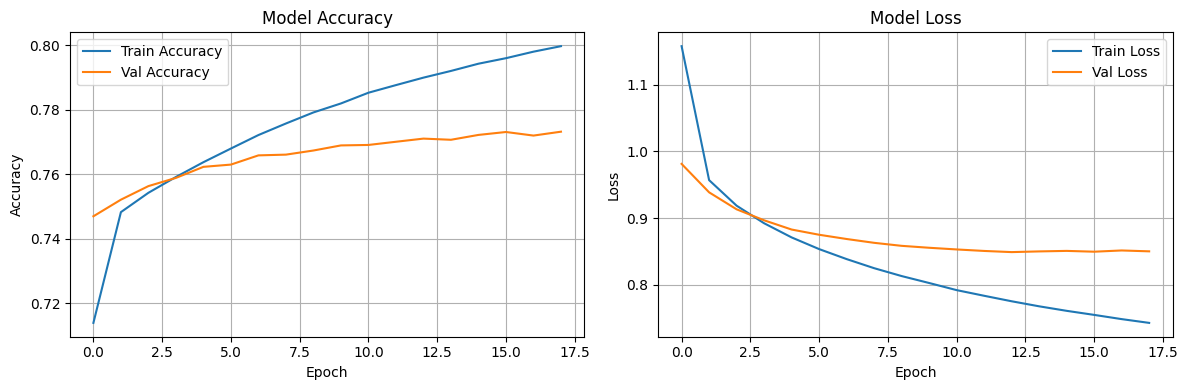

Plot saved as training_curves.png


In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["accuracy"],     label="Train Accuracy")
ax1.plot(history.history["val_accuracy"], label="Val Accuracy")
ax1.set_title("Model Accuracy"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.legend(); ax1.grid(True)

ax2.plot(history.history["loss"],     label="Train Loss")
ax2.plot(history.history["val_loss"], label="Val Loss")
ax2.set_title("Model Loss"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Plot saved as training_curves.png")

## Save Model and Vocabulary

In [34]:
MODEL_PATH  = "autocorrect_model.h5"
VOCAB_PATH  = "vocab.pkl"
CONFIG_PATH = "config.pkl"

model.save(MODEL_PATH)

with open(VOCAB_PATH, "wb") as f:
    pickle.dump((vocab, inv_vocab), f)

with open(CONFIG_PATH, "wb") as f:
    pickle.dump({"max_len": MAX_LEN, "vocab_size": vocab_size}, f)

print(f"Model saved  -> {MODEL_PATH}")
print(f"Vocab saved  -> {VOCAB_PATH}")
print(f"Config saved -> {CONFIG_PATH}")

Model saved  -> autocorrect_model.h5
Vocab saved  -> vocab.pkl
Config saved -> config.pkl


## Prediction Function

In [35]:
from difflib import get_close_matches

def dictionary_correct(word):
    """
    Find closest matching word from BASE_WORDS
    """
    matches = get_close_matches(word, BASE_WORDS, n=1, cutoff=0.6)
    return matches[0] if matches else word

In [36]:
def correct_word(word):
    tokens = word.strip().split()
    corrected = []

    for tok in tokens:
        x = np.array([encode(tok, vocab, MAX_LEN)])

        pred = model.predict(x, verbose=0)[0]

        decoded_word = decode_prediction(pred, inv_vocab)

        # Apply dictionary correction
        decoded_word = dictionary_correct(decoded_word)

        # fallback if empty
        if not decoded_word:
            decoded_word = tok

        corrected.append(decoded_word)

    return " ".join(corrected)

test_words = ["teh", "enviroment", "recieve", "frend", "languge", "comuter", "databse"]

print(f"{'Misspelled':<20} Corrected")
print("-" * 35)

for w in test_words:
    print(f"{w:<20} {correct_word(w)}")

Misspelled           Corrected
-----------------------------------
teh                  tee
enviroment           environment
recieve              receive
frend                friend
languge              language
comuter              computer
databse              data


## Try Your Own Word
Change `my_word` below and re-run this cell.

In [37]:
my_word = "algorythm"

result = correct_word(my_word)

print(f"Input  : {my_word}")
print(f"Output : {result}")

Input  : algorythm
Output : algorithm
